# Setup

In [3]:
import pandas as pd
from pathlib import Path
import torch
import transformer_lens
import gc
import itertools
import random
from sklearn.svm import LinearSVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

#MODEL_NAME = "EleutherAI/pythia-12b"
MODEL_NAME = "microsoft/phi-2"
USE_GPU = False

In [4]:
# Loading the model

if "model" in locals() or "model" in globals():
    del model

torch.cuda.empty_cache()

gc.collect()

# 4. Verify memory is cleared
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

# Load the Pythia-2.8b model
# This will download the model weights if they are not already cached.
model = transformer_lens.HookedTransformer.from_pretrained_no_processing(
    MODEL_NAME,
    device="cuda" if torch.cuda.is_available() and USE_GPU else "cpu",
    # dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)

print(f"{MODEL_NAME} model loaded successfully.")

GPU memory allocated: 4447.18 MB
GPU memory reserved: 4464.00 MB


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.50it/s]


Loaded pretrained model microsoft/phi-2 into HookedTransformer
microsoft/phi-2 model loaded successfully.


In [5]:
# Get the first MLP layer (layer 0)
first_mlp = model.blocks[0].mlp

# Get all parameters in the first MLP layer
for name, param in first_mlp.named_parameters():
    print(f"Parameter: {name}")
    print(f"Shape: {param.shape}")
    print(f"Data type: {param.dtype}")
    print(f"Device: {param.device}")
    print("---")

Parameter: W_in
Shape: torch.Size([2560, 10240])
Data type: torch.float32
Device: cpu
---
Parameter: b_in
Shape: torch.Size([10240])
Data type: torch.float32
Device: cpu
---
Parameter: W_out
Shape: torch.Size([10240, 2560])
Data type: torch.float32
Device: cpu
---
Parameter: b_out
Shape: torch.Size([2560])
Data type: torch.float32
Device: cpu
---


In [6]:
mlp_dim = model.blocks[0].mlp.b_in.shape[0]
magnitudes = []
for i in range(mlp_dim):
    normal = first_mlp.W_in[:, i].detach().cpu().numpy()
    magnitude = np.linalg.norm(normal)

    magnitudes.append(magnitude)

print(f"Magnitude statistics:")
print(f"Size: {len(magnitudes)}")
print(f"Mean: {np.mean(magnitudes):.4f}")
print(f"Std: {np.std(magnitudes):.4f}")
print(f"Min: {np.min(magnitudes):.4f}")
print(f"Max: {np.max(magnitudes):.4f}")
print(f"Median: {np.median(magnitudes):.4f}")
percentiles = np.percentile(magnitudes, [10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
for i, p in enumerate([10, 20, 30, 40, 50, 60, 70, 80, 90, 100]):
    print(f"{p}th percentile: {percentiles[i]:.4f}")

Magnitude statistics:
Size: 10240
Mean: 0.8182
Std: 0.5353
Min: 0.0274
Max: 2.0938
Median: 1.0737
10th percentile: 0.0317
20th percentile: 0.0339
30th percentile: 0.3310
40th percentile: 0.7725
50th percentile: 1.0737
60th percentile: 1.1745
70th percentile: 1.2493
80th percentile: 1.3077
90th percentile: 1.3790
100th percentile: 2.0938


Projection statistics layer 0:
Size: 10240
Mean: 0.1772
Std: 0.1570
Min: -1.6923
Max: 0.6967
Median: 0.2455

Distance statistics layer 0:
Size: 10240
Mean: -0.0150
Std: 0.0121
Min: -0.1444
Max: 0.0358
Median: -0.0118

Comparison to -1:
< -1: 2 (0.02%)
= -1: 0 (0.00%)
> -1: 10238 (99.98%)

Projection statistics layer 8:
Size: 10240
Mean: 0.1003
Std: 0.9346
Min: -2.9718
Max: 3.9027
Median: -0.0082

Distance statistics layer 8:
Size: 10240
Mean: -0.0136
Std: 0.0156
Min: -0.1243
Max: 0.2321
Median: -0.0170

Comparison to -1:
< -1: 656 (6.41%)
= -1: 0 (0.00%)
> -1: 9584 (93.59%)

Projection statistics layer 16:
Size: 10240
Mean: -0.0265
Std: 0.9699
Min: -3.8190
Max: 3.5538
Median: -0.3547

Distance statistics layer 16:
Size: 10240
Mean: -0.0117
Std: 0.0127
Min: -0.0685
Max: 0.0850
Median: -0.0135

Comparison to -1:
< -1: 1267 (12.37%)
= -1: 0 (0.00%)
> -1: 8973 (87.63%)

Projection statistics layer 24:
Size: 10240
Mean: -0.0363
Std: 0.8169
Min: -3.5948
Max: 3.7893
Median: -0.2277

Distance 

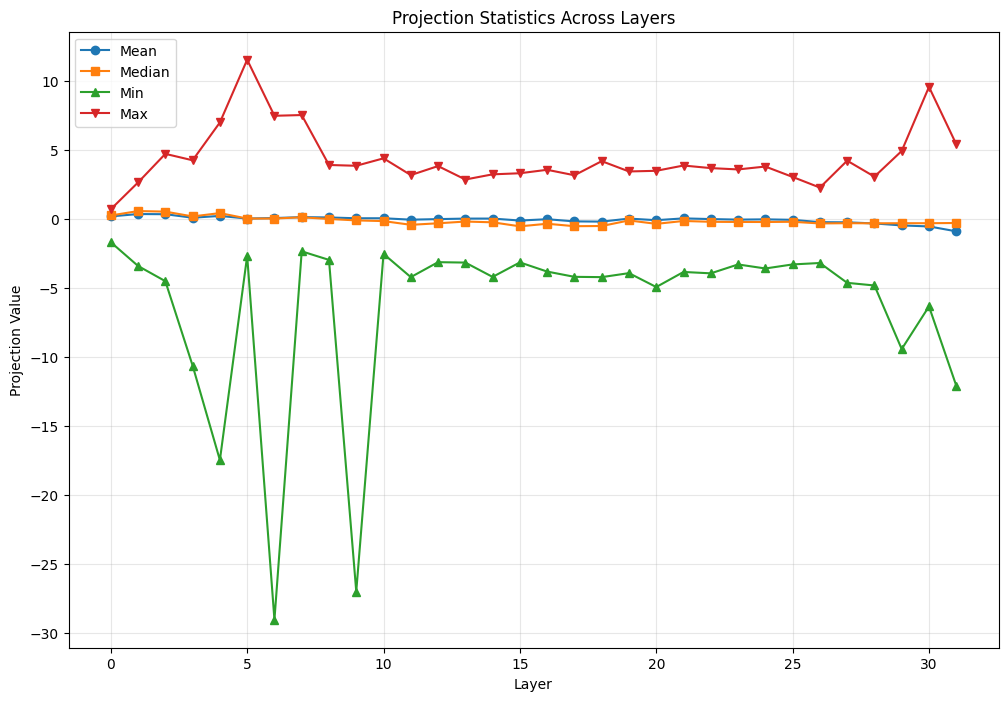

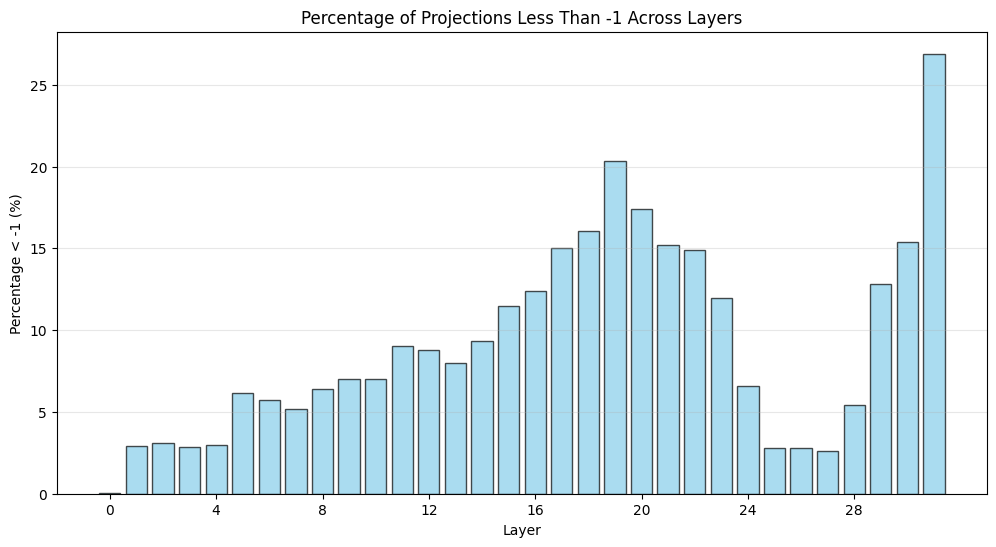

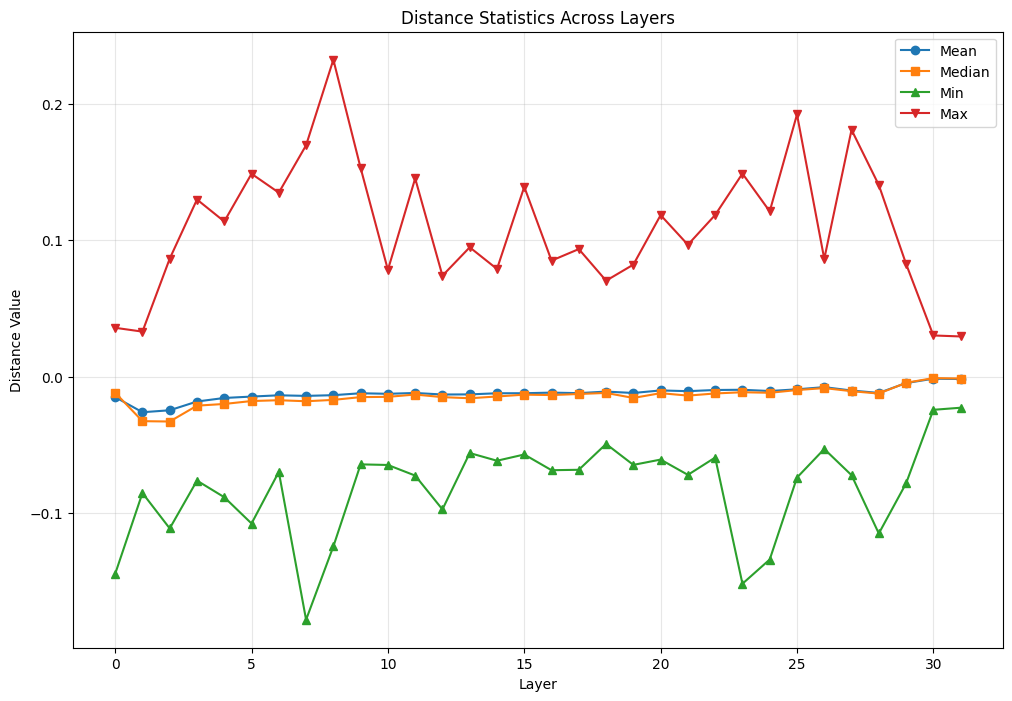

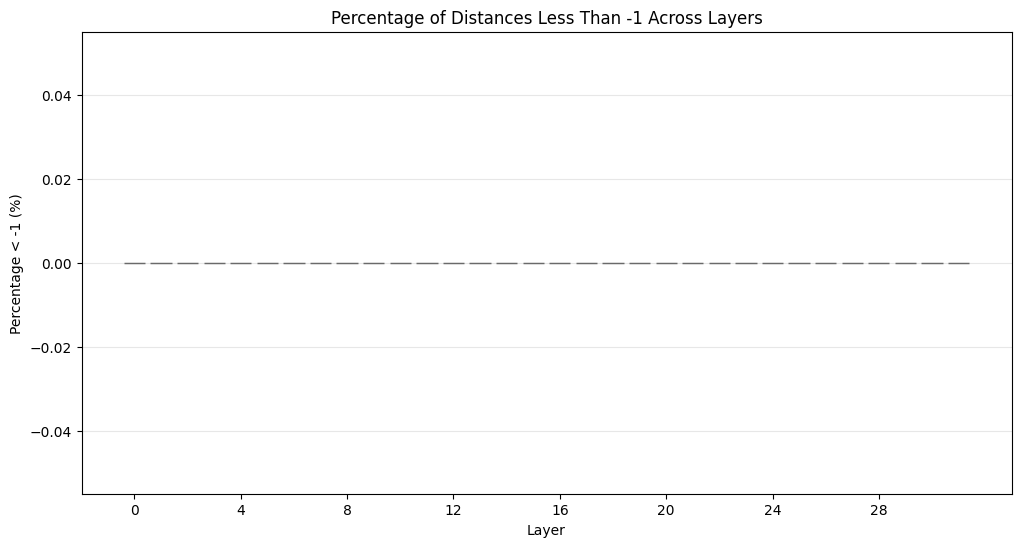

In [7]:
projections_per_layer = {}
distances_per_layer = {}
for layer in range(len(model.blocks)):
    projections_per_layer[layer] = []
    distances_per_layer[layer] = []
    for i in range(mlp_dim):
        normal = model.blocks[layer].mlp.W_in[:, i].detach().cpu().numpy()
        translation = model.blocks[layer].mlp.W_out[i, :].detach().cpu().numpy()
        projections_per_layer[layer].append(np.dot(normal, translation))
        b_in = model.blocks[layer].mlp.b_in[i].detach().cpu().numpy()
        distances_per_layer[layer].append(b_in / np.linalg.norm(normal))

    if layer%8 == 0 or layer == len(model.blocks) - 1:
        print(f"Projection statistics layer {layer}:")
        print(f"Size: {len(projections_per_layer[layer])}")
        print(f"Mean: {np.mean(projections_per_layer[layer]):.4f}")
        print(f"Std: {np.std(projections_per_layer[layer]):.4f}")
        print(f"Min: {np.min(projections_per_layer[layer]):.4f}")
        print(f"Max: {np.max(projections_per_layer[layer]):.4f}")
        print(f"Median: {np.median(projections_per_layer[layer]):.4f}")

        print(f"\nDistance statistics layer {layer}:")
        print(f"Size: {len(distances_per_layer[layer])}")
        print(f"Mean: {np.mean(distances_per_layer[layer]):.4f}")
        print(f"Std: {np.std(distances_per_layer[layer]):.4f}")
        print(f"Min: {np.min(distances_per_layer[layer]):.4f}")
        print(f"Max: {np.max(distances_per_layer[layer]):.4f}")
        print(f"Median: {np.median(distances_per_layer[layer]):.4f}")

        # Count values relative to -1
        less_than_neg1 = sum(1 for p in projections_per_layer[layer] if p < -1)
        equal_to_neg1 = sum(1 for p in projections_per_layer[layer] if p == -1)
        greater_than_neg1 = sum(1 for p in projections_per_layer[layer] if p > -1)

        print(f"\nComparison to -1:")
        print(f"< -1: {less_than_neg1} ({less_than_neg1/len(projections_per_layer[layer])*100:.2f}%)")
        print(f"= -1: {equal_to_neg1} ({equal_to_neg1/len(projections_per_layer[layer])*100:.2f}%)")
        print(f"> -1: {greater_than_neg1} ({greater_than_neg1/len(projections_per_layer[layer])*100:.2f}%)\n")

# Extract statistics for plotting
layers = list(projections_per_layer.keys())
means = [np.mean(projections_per_layer[layer]) for layer in layers]
medians = [np.median(projections_per_layer[layer]) for layer in layers]
mins = [np.min(projections_per_layer[layer]) for layer in layers]
maxs = [np.max(projections_per_layer[layer]) for layer in layers]

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(layers, means, label='Mean', marker='o')
plt.plot(layers, medians, label='Median', marker='s')
plt.plot(layers, mins, label='Min', marker='^')
plt.plot(layers, maxs, label='Max', marker='v')

plt.xlabel('Layer')
plt.ylabel('Projection Value')
plt.title('Projection Statistics Across Layers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate percentage of projections less than -1 for each layer
percentages_less_than_neg1 = []
for layer in layers:
    projections = projections_per_layer[layer]
    count_less_than_neg1 = sum(1 for p in projections if p < -1)
    percentage = (count_less_than_neg1 / len(projections)) * 100
    percentages_less_than_neg1.append(percentage)

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(layers, percentages_less_than_neg1, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Layer')
plt.ylabel('Percentage < -1 (%)')
plt.title('Percentage of Projections Less Than -1 Across Layers')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(0, len(layers), 4))  # Show every 4th layer for clarity
plt.show()

#Plot for distances:
means = [np.mean(distances_per_layer[layer]) for layer in layers]
medians = [np.median(distances_per_layer[layer]) for layer in layers]
mins = [np.min(distances_per_layer[layer]) for layer in layers]
maxs = [np.max(distances_per_layer[layer]) for layer in layers]

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(layers, means, label='Mean', marker='o')
plt.plot(layers, medians, label='Median', marker='s')
plt.plot(layers, mins, label='Min', marker='^')
plt.plot(layers, maxs, label='Max', marker='v')

plt.xlabel('Layer')
plt.ylabel('Distance Value')
plt.title('Distance Statistics Across Layers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate percentage of distances less than -1 for each layer
percentages_less_than_neg1 = []
for layer in layers:
    distances = distances_per_layer[layer]
    count_less_than_neg1 = sum(1 for d in distances if d < -1)
    percentage = (count_less_than_neg1 / len(distances)) * 100
    percentages_less_than_neg1.append(percentage)

# Create bar plot
plt.figure(figsize=(12, 6))
plt.bar(layers, percentages_less_than_neg1, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Layer')
plt.ylabel('Percentage < -1 (%)')
plt.title('Percentage of Distances Less Than -1 Across Layers')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(range(0, len(layers), 4))  # Show every 4th layer for clarity
plt.show()